# 3D：バルクCLN＋表面補足、Foster、PODを区別して比較する

**今回の境界ポート補足は十分には効きませんでした。実際の励振の場から作るPODは有効でした。** 表面モードの有無だけで精度は決まりません。基底をどの励振・帯域から選ぶかが重要です。

[前の実験](07_surface_hybrid_foster.ipynb)は、非線形2Dの表面補足と、3Dの端子帯域フィットを扱いました。このノートは実際の3D有限要素モデルで、通常CLN、バルク2状態＋表面補足、実際の励振によるPODを比較します。

「バルク2」は磁気場2状態、元のType1では正のR/L合計4要素です。表面との結合を残した後、それを2段の物理的回路として保持できたという意味ではありません。Codex自己レビュー済み、Claudeの独立レビューは未実施です。

## 同じ3Dモデル、同じ誤差基準

切欠き付き導体、線形材料、A–φ。全境界でAの接線成分を固定し、φの端面値を指定します。スカラー補正をSchur消去し、curlの勾配核を除いた同じ正定値行列対 $(K,M)$ を全方式に使います。外部空気を含む実機全体のモデルではありません。

正規化した磁気反作用は $Z(u)=u f^T(K+uM)^{-1}f$、$u=s\tau$ です。全自由度の一般化固有モードを参照値とし、6周波数の直接解で場も確認します。

比較帯域は1 kHz〜1 MHz、行列の無次元展開点は $u_0=s_0\tau$、通常CLNの実展開点は $s_0=2\pi\,10^4$。総状態数を4/8/12にそろえます。端子応答だけでなく、固定エネルギー $K+u_0M$ による場の誤差、ジュール損失、磁気エネルギーも検査します。

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
DATA=Path('data')
coarse=json.loads((DATA/'surface_3d_coarse.json').read_text())
fine=json.loads((DATA/'surface_3d_fine.json').read_text())
print('メッシュ / 導体の物理自由度:', [(d['mesh']['ne'],d['mesh']['physical_dimension']) for d in [coarse,fine]])
print('直接解との場の相対差:', [d['direct_field_reference_difference'] for d in [coarse,fine]])


メッシュ / 導体の物理自由度: [(434, 305), (1640, 1399)]
直接解との場の相対差: [2.1625387161248364e-15, 5.70085561265969e-15]


## 表面モードを加えたらPODなのか？

次の二つは区別できます。

- **境界ポート＋QR**：境界上の滑らかな磁束密度の汎関数から場の補足候補を作り、QRで独立な候補を選ぶ。今回はこちらをPODとは呼びません。
- **スナップショット＋打切りSVD**：多数の応答場から、指定した重みで二乗誤差を小さくする方向を選ぶ。こちらはPODです。

今回の「surface POD」は**仮想境界ポートの応答スナップショットに対するPOD**です。「physical-port POD」は**実際の励振の応答場に対するPOD**です。学習する励振が違うので、同じ状態数でも異なる結果になります。[PODと事前計算の位置づけ](https://pmc.ncbi.nlm.nih.gov/articles/PMC3672853/)も参照してください。

単なるSVDによる独立性の検査と、重要な特異方向を選ぶPOD打切りも区別します。

## 表面補足の具体的な作り方

外形6面の中心付近に、接線2方向ずつ、合計12個の滑らかな磁気トレース汎関数を置きます。各汎関数は、幅7 mmのGaussian重み $w_j$ により

$$g_j(A)=\int_{\partial\Omega}w_j\,d_j\cdot\operatorname{curl}A\,dS$$

とします。切欠き面も積分面に含みますが、今回の12中心は外形面に配置しています。NGSolveの体積側から評価した磁束密度を使います。通常のH(div)法線トレースだけでは今回の境界条件でゼロになるため、これを接線磁束の代用にはしません。

$ (K+\sigma_j M)^{-1}g_j $ を1 kHz〜1 MHzの4つの**実シフト**で作り、48候補とします。全候補を同じエネルギーで規格化し、バルク2状態への成分を除いてからQRまたはPODで補足を選びます。物理的な入力 $f$ は変更しません。

これは仮想境界ポートからの場の補足です。外部空気のDtN/Steklov消去、解析的な表皮層、メッシュにない情報を追加した方法ではありません。今回の不振を、すべての表面モード法の不振とは解釈しません。

## 回路表現：結合行列を先に評価する

基底 $Q$ を混ぜると、$K_q=Q^TKQ$ と $M_q=Q^TMQ$ にバルク・表面の結合が残ります。CLNの段別漸化式や直交関係をそのまま満たす保証はありません。**表面補足後の物理的CLNはしご回路を導出したとは扱いません。**

線形・正定値・同一入出力の今回のモデルでは、結合行列の一般化固有問題

$$K_qv_j=p_j M_qv_j,\qquad v_i^TM_qv_j=\delta_{ij}$$

から、端子等価Foster表現

$$Z_q(u)=\sum_j r_j\frac{u}{u+p_j},\qquad r_j=(f_q^Tv_j)^2\geq0$$

を作れます。正規化変数 $u$ の回路では、各枝を $R_j=r_j$、$L_j=r_j/p_j$ の並列RLとして直列に接続します。物理単位への換算には時間・端子の規格化を戻す必要があります。これは結合を含めて対角化した結果であり、「各表面モードに独立枝を追加した」ものではありません。元のバルク・表面座標の物理的対応は混ざります。非線形系にそのまま固定Fosterを使えるという保証でもありません。

In [2]:
labels=['bulk CLN 2','ordinary CLN 4','bulk2 + surface QR 4','bulk2 + surface POD 4',
        'bulk2 + physical-port residual POD 4','physical-port POD 4']
print('細メッシュ: 1kHz〜1MHz、%単位')
print(f"{'方式':43s} {'端子最大':>10s} {'場最大':>10s} {'DC傾き':>10s}")
for label in labels:
    v=fine['runs'][label]
    print(f"{label:43s} {100*v['high_band_max']:10.5f} {100*v['field_high_band_max']:10.5f} {100*v['DC_slope_error']:10.5f}")
print('全縮約モデル: 結合行列対Foster最大相対差',max(v['coupled_vs_foster'] for d in [coarse,fine] for v in d['runs'].values()))
print('バルク/表面結合指標(8状態、POD前の座標を保持):',fine['runs']['bulk2 + surface POD 8']['bulk_surface_coupling_ratio'])


細メッシュ: 1kHz〜1MHz、%単位
方式                                                端子最大        場最大       DC傾き
bulk CLN 2                                     4.61147   52.83348    0.03182
ordinary CLN 4                                 1.06574   30.10261    0.00001
bulk2 + surface QR 4                           4.60706   52.82359    0.03180
bulk2 + surface POD 4                          4.61004   52.84001    0.03182
bulk2 + physical-port residual POD 4           0.04938    5.77465    0.00406
physical-port POD 4                            0.03038    5.34979    0.01539
全縮約モデル: 結合行列対Foster最大相対差 9.670787924691496e-15
バルク/表面結合指標(8状態、POD前の座標を保持): 0.007895910170295369


## 励振に合わせたPODは有効、ただし事前計算が必要

実際の入力 $f$ に対する31周波数（1 kHz〜1 MHz）の全自由度の複素場を事前に計算します。各複素場を $K+u_0M$ のエネルギーで規格化し、実部・虚部を並べた62列からPODを作ります。重みの選び方も近似の仕様です。$K+u_0M$ は磁気項と重み付き損失項を合わせた正定値内積であり、磁気の蓄積エネルギーだけではありません。

「bulk2 + physical-port residual POD」は、バルク2状態で説明できない**全領域の場**をPODで補足します。これは表面局在モードであることを保証していません。PODだけの方式も同じ全自由度スナップショットを使用します。

参照値評価は301周波数。学習周波数と一致する点を除いた結果も保存しています。事前計算には全系の情報が必要なので、CLNと同じ構築費用で得られたとは比較しません。今回の密行列・全固有系による実行時間は、産業規模の疎行列での速度評価ではありません。

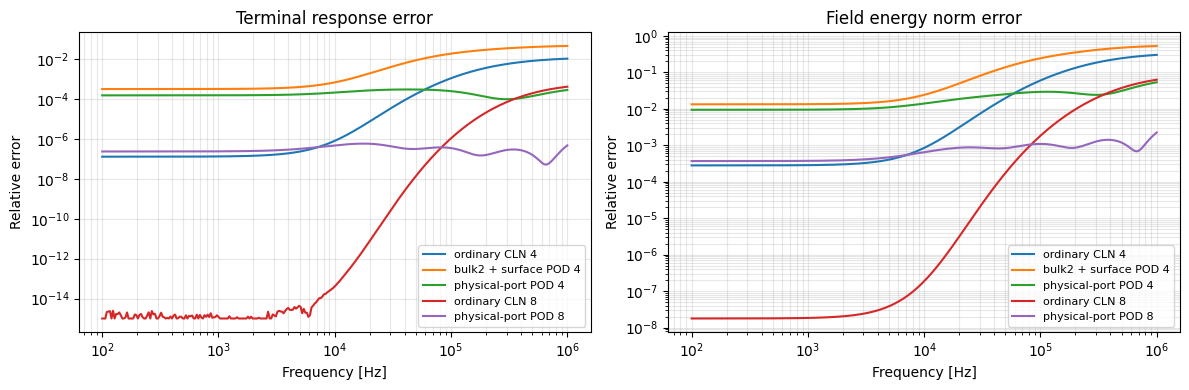

POD 4: 学習点を除く高帯域の端子最大誤差 [%] 0.030376216749583025
注意: 端子の0.0304%に対し、場の最大誤差は約5.35%。端子精度と場の精度は別です。


In [3]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
for label in ['ordinary CLN 4','bulk2 + surface POD 4','physical-port POD 4',
              'ordinary CLN 8','physical-port POD 8']:
    v=fine['runs'][label]
    axes[0].loglog(fine['frequency_hz'],np.maximum(v['relative_error'],1e-15),label=label)
    axes[1].loglog(fine['frequency_hz'],np.maximum(v['field_energy_relative_error'],1e-15),label=label)
axes[0].set_title('Terminal response error');axes[1].set_title('Field energy norm error')
for ax in axes:
    ax.set_xlabel('Frequency [Hz]');ax.set_ylabel('Relative error');ax.grid(True,which='both',alpha=.3);ax.legend(fontsize=8)
plt.tight_layout();plt.show()
print('POD 4: 学習点を除く高帯域の端子最大誤差 [%]',100*fine['runs']['physical-port POD 4']['holdout_high_band_max'])
print('注意: 端子の0.0304%に対し、場の最大誤差は約5.35%。端子精度と場の精度は別です。')


In [4]:
print('状態数とメッシュの比較: 最大端子誤差 [%]')
for n in [4,8,12]:
    for prefix in ['ordinary CLN','bulk2 + surface QR','bulk2 + surface POD','physical-port POD']:
        label=f'{prefix} {n}'
        print(label, [100*d['runs'][label]['high_band_max'] for d in [coarse,fine]])
a=np.asarray(coarse['reference_real'])+1j*np.asarray(coarse['reference_imag'])
b=np.asarray(fine['reference_real'])+1j*np.asarray(fine['reference_imag'])
print('正規化全自由度応答のメッシュ間最大差 [%]',100*np.max(abs(a/b-1)))
print('静的係数のメッシュ間相対差 [%]',100*abs(coarse['mesh']['static_H']/fine['mesh']['static_H']-1))


状態数とメッシュの比較: 最大端子誤差 [%]
ordinary CLN 4 [0.35739654520289865, 1.0657377774692518]
bulk2 + surface QR 4 [2.9159139827797174, 4.607060760198746]
bulk2 + surface POD 4 [2.8140846017244923, 4.610035141387575]
physical-port POD 4 [0.015478055365612697, 0.030376216749583025]
ordinary CLN 8 [0.005226163591017404, 0.041749239980994494]
bulk2 + surface QR 8 [2.871532032391038, 4.590544949832394]
bulk2 + surface POD 8 [2.79835883068337, 4.4722364744786685]
physical-port POD 8 [3.833178059140462e-06, 5.85125739113895e-05]
ordinary CLN 12 [0.00010423304081937426, 0.0027959091114776544]
bulk2 + surface QR 12 [2.29870244498706, 3.6447343378592505]
bulk2 + surface POD 12 [2.764234960312285, 4.4302953578947575]
physical-port POD 12 [5.38651535253872e-10, 3.613645798590639e-08]
正規化全自由度応答のメッシュ間最大差 [%] 3.456172544280294
静的係数のメッシュ間相対差 [%] 7.1909015256503945


## 結果の読み方

今回の細メッシュ・4状態では、通常CLNの端子最大誤差は約1.066%、境界ポート補足は約4.61%、実際の励振のPODは約0.0304%でした。境界ポート補足は今回のバルク2状態だけ（約4.61%）からほとんど改善しませんでした。選んだ境界ポートと打切り方が、必要な場を十分に表さなかったという結果です。

したがって、現状では「表面補足でバルク2段にできる」「Fosterなら自動的に良くなる」とは言えません。一方、励振と帯域に合わせたPOD＋Foster端子等価回路は、この離散系で有効でした。これはPODによる**基底選択**の効果であり、Fosterという回路形式に変えた効果ではありません。

二つのメッシュの全自由度応答には約3.46%の差が残ります。同じ離散系への小さい縮約誤差を、実物や連続体への誤差としては扱いません。表皮層のメッシュ解像度を回路表現だけで回復したとも言えません。

今後の課題は、励振に合う境界モード、切欠き付近の局所補足、真の境界演算子との組合せ、物理的なバルク/表面回路への変換です。今回の比較がそれらを実装済み・解決済みという意味ではありません。

## 再計算と保存結果の検証

図表はこのノート内に実行済み出力として保存しています。[再計算コード](../validation/surface_hybrid/compare_surface_3d.py)と[モデル構築](../validation/surface_hybrid/surface_3d_model.py)を同梱しています。

```text
python validation/surface_hybrid/compare_surface_3d.py --maxh .004 --output coarse.json
python validation/surface_hybrid/compare_surface_3d.py --maxh .003 --output fine.json
python validation/surface_hybrid/validate_surface_3d.py
```

FEM再計算にはNGSolve、numpy、scipyが必要です。保存結果の検証にはnumpyだけを使います。ソースのLF正規化ハッシュ、正の極・非負の残差、Foster再構成、状態数、結合と誤差を検査します。
